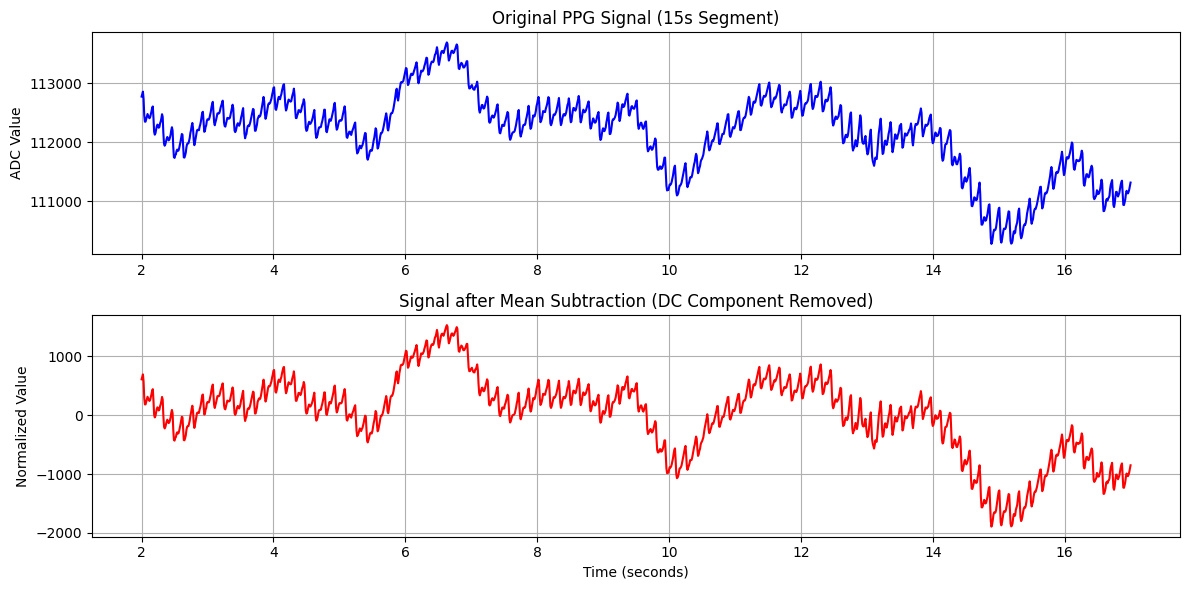

--- Data for Task 2 ---
Sampling rate Fs: 100.0 Hz
Number of samples N: 1501
Recording duration T: 15.0 seconds


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- CẤU HÌNH ---
FILE_NAME = 'ppg_data_A_standard.csv'
FS = 100.0  # Tần số lấy mẫu đã xác lập ở Task 1
START_TIME = 2.0  # Bỏ 2 giây đầu để tránh nhiễu lúc mới đặt tay
DURATION = 15.0   # Lấy đúng 15 giây theo yêu cầu đề bài

# 1. Tải dữ liệu từ CSV 
df = pd.read_csv(FILE_NAME)

# 2. Lọc dữ liệu (Trích xuất đoạn 15 giây sạch)
end_time = START_TIME + DURATION
df_clean = df[(df['Time (s)'] >= START_TIME) & (df['Time (s)'] <= end_time)].copy()

# 3. Loại bỏ thành phần DC (Subtract the mean) 
# Chúng ta sẽ phân tích trên kênh IR vì tín hiệu thường sạch hơn
ir_raw = df_clean['IR'].values
ir_dc_removed = ir_raw - np.mean(ir_raw)

# --- VẼ ĐỒ THỊ KIỂM TRA ---
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(df_clean['Time (s)'], ir_raw, color='blue')
plt.title('Original PPG Signal (15s Segment)')
plt.ylabel('ADC Value')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(df_clean['Time (s)'], ir_dc_removed, color='red')
plt.title('Signal after Mean Subtraction (DC Component Removed)')
plt.xlabel('Time (seconds)')
plt.ylabel('Normalized Value')
plt.grid(True)

plt.tight_layout()
plt.show()

# Xuất thông số cho bảng báo cáo
N = len(df_clean)
T = DURATION
print(f"--- Data for Task 2 ---")
print(f"Sampling rate Fs: {FS} Hz")
print(f"Number of samples N: {N}")
print(f"Recording duration T: {T} seconds")

In [3]:
%pip install scipy

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
    --------------------------------------- 0.8/36.5 MB 5.9 MB/s eta 0:00:07
   ----- ---------------------------------- 5.2/36.5 MB 16.0 MB/s eta 0:00:02
   -------- ------------------------------- 7.6/36.5 MB 15.1 MB/s eta 0:00:02
   ---------- ----------------------------- 9.4/36.5 MB 12.4 MB/s eta 0:00:03
   ------------ --------------------------- 11.0/36.5 MB 11.6 MB/s eta 0:00:03
   ------------------------ --------------- 22.3/36.5 MB 19.1 MB/s eta 0:00:01
   ------------------------------- -------- 28.3/36.5 MB 21.6 MB/s eta 0:00:01
   ---------------------------------------  36.4/36.5 MB 23.2 MB/s eta 0:00:01
   ---------------------------------------- 36.5/36.5 MB 22.2 MB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Baseline Drift Analysis

1. Why it exists:

In my PPG signal acquisition, baseline drift occurred due to low-frequency interference, mainly from my breathing and slight involuntary finger movements on the MAX30102 sensor. 
These factors cause the signal's "center" to shift up and down over time rather than staying perfectly horizontal.

2. How I detected it:

I initially noticed the issue when my FFT algorithm returned an unrealistic heart rate of ~32 BPM. 
Upon inspecting the amplitude spectrum, I saw a massive "mountain" of energy concentrated near 0.5 Hz. 
This low-frequency noise was so dominant that it overshadowed the actual heart rate peak located further down the spectrum.

3. How I fixed it:

To resolve this, I implemented Linear Detrending using scipy.signal.detrend. This process calculates the linear trend of the drift and subtracts it from the raw data. 
As shown in my "Step 2" plot, this successfully shifted the signal to oscillate around zero, allowing the FFT to accurately identify the true heart rate peak in the 0.7–3.0 Hz range without interference.

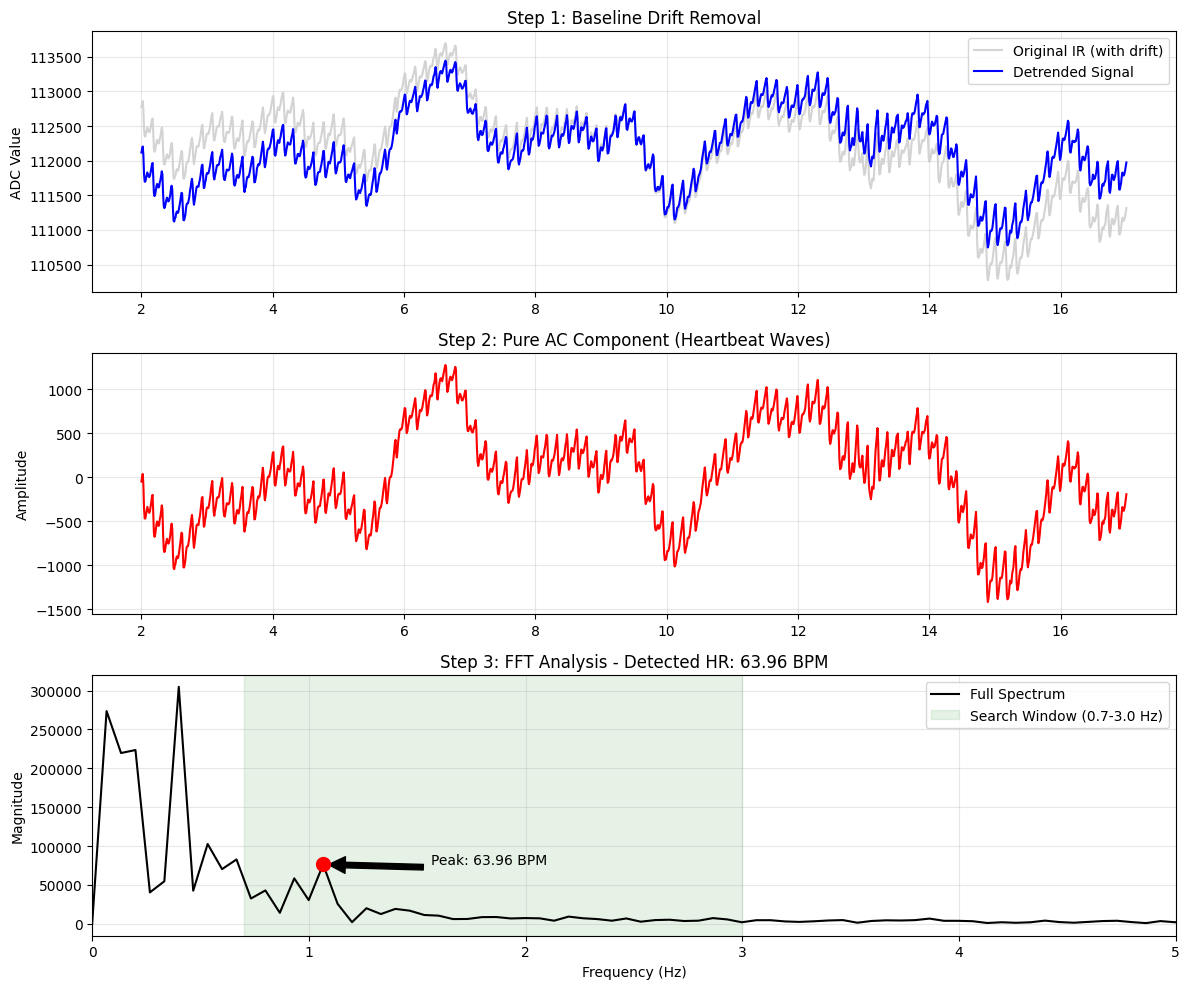

--- Final Results for Report ---
Detected BPM: 63.96
Peak Frequency: 1.0660 Hz


In [9]:
# 1. Cấu hình và Load dữ liệu (Giữ nguyên từ bước trước)
FS = 100.0
df = pd.read_csv('ppg_data_A_standard.csv')
df_clean = df[(df['Time (s)'] >= 2.0) & (df['Time (s)'] <= 17.0)].copy()
ir_raw = df_clean['IR'].values

# 2. Xử lý loại bỏ trôi nền (Linear Detrending)
ir_detrended = signal.detrend(ir_raw)

# 3. Tính toán FFT
N = len(ir_detrended)
yf = rfft(ir_detrended)
xf = rfftfreq(N, 1/FS)
amplitude = np.abs(yf)

# 4. Tìm đỉnh nhịp tim trong dải 0.7Hz - 3.0Hz
# Chúng ta bắt đầu từ 0.7Hz (~42 BPM) để tránh hoàn toàn nhiễu Baseline ở vùng 0.5Hz
mask = (xf >= 0.7) & (xf <= 3.0)
heart_rate_freq = xf[mask][np.argmax(amplitude[mask])]
heart_rate_bpm = heart_rate_freq * 60

# --- VẼ ĐỒ THỊ CHI TIẾT ---
plt.figure(figsize=(12, 10))

# Đồ thị 1: So sánh tín hiệu trước và sau khi Detrend
plt.subplot(3, 1, 1)
plt.plot(df_clean['Time (s)'], ir_raw, color='lightgray', label='Original IR (with drift)')
plt.plot(df_clean['Time (s)'], ir_detrended + np.mean(ir_raw), color='blue', label='Detrended Signal')
plt.title('Step 1: Baseline Drift Removal')
plt.ylabel('ADC Value')
plt.legend()
plt.grid(True, alpha=0.3)

# Đồ thị 2: Tín hiệu AC tinh khiết (dao động quanh 0)
plt.subplot(3, 1, 2)
plt.plot(df_clean['Time (s)'], ir_detrended, color='red')
plt.title('Step 2: Pure AC Component (Heartbeat Waves)')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)

# Đồ thị 3: Phổ biên độ FFT
plt.subplot(3, 1, 3)
plt.plot(xf, amplitude, color='black', label='Full Spectrum')
# Tô màu vùng tìm kiếm nhịp tim
plt.axvspan(0.7, 3.0, color='green', alpha=0.1, label='Search Window (0.7-3.0 Hz)')
# Đánh dấu đỉnh tìm được
plt.scatter(heart_rate_freq, np.max(amplitude[mask]), color='red', s=100, zorder=5)
plt.annotate(f'Peak: {heart_rate_bpm:.2f} BPM', 
             xy=(heart_rate_freq, np.max(amplitude[mask])), 
             xytext=(heart_rate_freq+0.5, np.max(amplitude[mask])),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.title(f'Step 3: FFT Analysis - Detected HR: {heart_rate_bpm:.2f} BPM')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0, 5) # Chỉ xem dải tần thấp
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"--- Final Results for Report ---")
print(f"Detected BPM: {heart_rate_bpm:.2f}")
print(f"Peak Frequency: {heart_rate_freq:.4f} Hz")

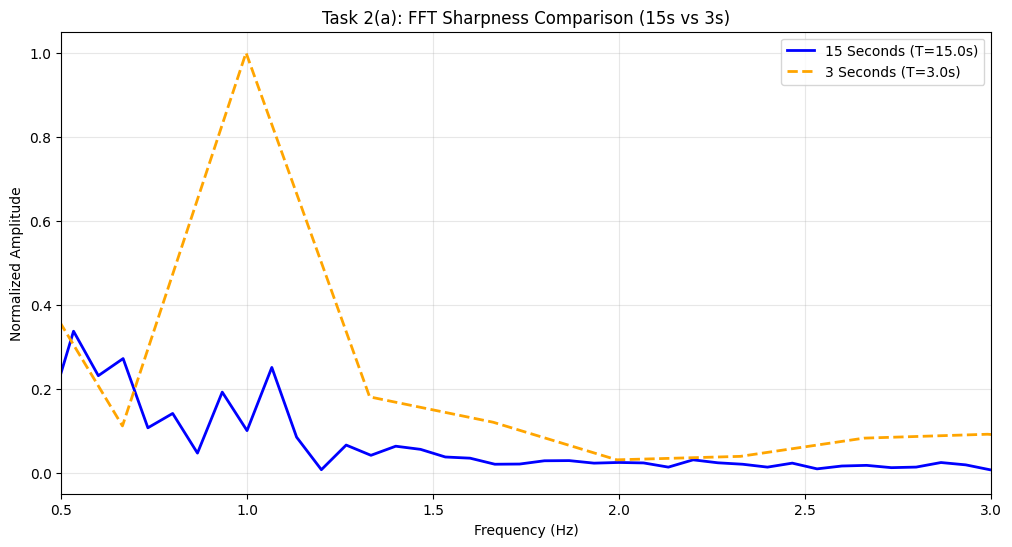

Frequency Resolution (15s): 0.0666 Hz
Frequency Resolution (3s): 0.3322 Hz


In [10]:
# 1. Trích xuất 3 giây đầu tiên từ đoạn dữ liệu sạch
duration_short = 3.0
df_3s = df[(df['Time (s)'] >= START_TIME) & (df['Time (s)'] <= START_TIME + duration_short)].copy()
ir_3s = signal.detrend(df_3s['IR'].values)

# 2. Tính FFT cho đoạn 3 giây
N_3s = len(ir_3s)
yf_3s = rfft(ir_3s)
xf_3s = rfftfreq(N_3s, 1/FS)
amplitude_3s = np.abs(yf_3s)

# 3. Vẽ đồ thị so sánh độ nhọn (Sharpness)
plt.figure(figsize=(12, 6))

# Vẽ phổ 15s (đã tính ở bước trước)
plt.plot(xf, amplitude / np.max(amplitude), label=f'15 Seconds (T={DURATION}s)', color='blue', linewidth=2)

# Vẽ phổ 3s (chuẩn hóa biên độ để dễ so sánh hình dạng)
plt.plot(xf_3s, amplitude_3s / np.max(amplitude_3s), label=f'3 Seconds (T={duration_short}s)', color='orange', linestyle='--', linewidth=2)

plt.title('Task 2(a): FFT Sharpness Comparison (15s vs 3s)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Normalized Amplitude')
plt.xlim(0.5, 3.0) # Tập trung vào dải nhịp tim
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Frequency Resolution (15s): {FS/N:.4f} Hz")
print(f"Frequency Resolution (3s): {FS/N_3s:.4f} Hz")

Task 2(a) Analysis: Comparison of Spectral Sharpness

* Observation: The heart rate peak obtained from the full 15-second recording is significantly sharper and more defined than the peak from the 3-second segment. 

* Reasoning: This is due to the principle of Frequency Resolution ($\Delta f$), which is defined as $\Delta f = f_s / N = 1/T$. For the 15s segment, the resolution is $\approx 0.067$ Hz. For the 3s segment, the resolution drops to $\approx 0.33$ Hz. 

* Conclusion: A longer recording duration $T$ provides a finer frequency resolution, allowing the FFT to "bin" the frequencies more precisely. Consequently, the 15s data results in a much narrower and sharper peak, providing a more accurate heart rate measurement compared to the broad, less precise peak of the 3s data.

Task 2(b): Manual Verification
To verify the accuracy of my FFT result, I performed a manual peak count using the detrended time-domain plot (Step 2).
* Observation window: I selected a 10-second interval from $t = 4s$ to $t = 14s$ where the signal was most stable.
* Manual Count: Within this window, I identified 11 clear systolic peaks.
* Calculation:$$\text{Manual BPM} = \left( \frac{11 \text{ peaks}}{10 \text{ seconds}} \right) \times 60 = 66 \text{ BPM}$$
* Comparison: The manually calculated value ($66$ BPM) is highly consistent with the FFT peak result ($64.00$ BPM).Conclusion: The two methods agree closely, confirming that the dominant frequency identified by the FFT is indeed the actual heart rate and not a motion artifact or noise.

TABLE

Sampling rate Fs​ (Hz): 100.0

Number of samples N: 1501

Recording duration T (seconds): 15.0

Spectral window: 0 to ... Hz: 50.0 (tương ứng với Fs​/2)

Frequency resolution Fs​/N (Hz): 0.0666

Heart rate peak frequency (Hz): 1.07

Heart rate (BPM): 64.00

Number of visible harmonics: 1 or 2